In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()


In [2]:
import pandas as pd
import ast

# 1. Create a clean copy of the raw data
df_india_clean = df.copy()

# 2. Safely parse strings to real python lists before exploding
df_india_clean['job_skills'] = df_india_clean['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# 3. Filter strictly for Data Scientists in India with valid salaries
df_ds_india = df_india_clean[
    (df_india_clean['job_country'] == 'India') & 
    (df_india_clean['job_title_short'] == 'Data Scientist')
].dropna(subset=['salary_year_avg'])

# 4. No of unique jobs of data science in india
total_ds_postings = len(df_ds_india)

In [3]:
#Explode for skills salary and job counts
df_ds_indiaexplode = df_ds_india.explode('job_skills')
df_ds_indiaexplode
df_optimal = df_ds_indiaexplode.groupby('job_skills')['salary_year_avg'].agg(median_salary = 'median',skill_count = 'count').reset_index()
df_optimal

df_optimal['skill_percentage'] = (df_optimal['skill_count'] / total_ds_postings) * 100
df_optimal
df_optimal2 = df_optimal[df_optimal['skill_percentage'] >= 10].copy()
df_optimal2

,job_skills,median_salary,skill_count,skill_percentage
5,aws,103550.00,20,21.739130
6,azure,157500.00,15,16.304348
27,hadoop,87717.75,14,15.217391
36,keras,122602.50,10,10.869565
52,python,152500.00,64,69.565217
53,pytorch,157500.00,10,10.869565
55,r,129758.00,30,32.608696
67,spark,93600.00,23,25.000000
69,sql,113500.00,49,53.260870
75,tableau,113500.00,19,20.652174


In [4]:
!pip install adjustText

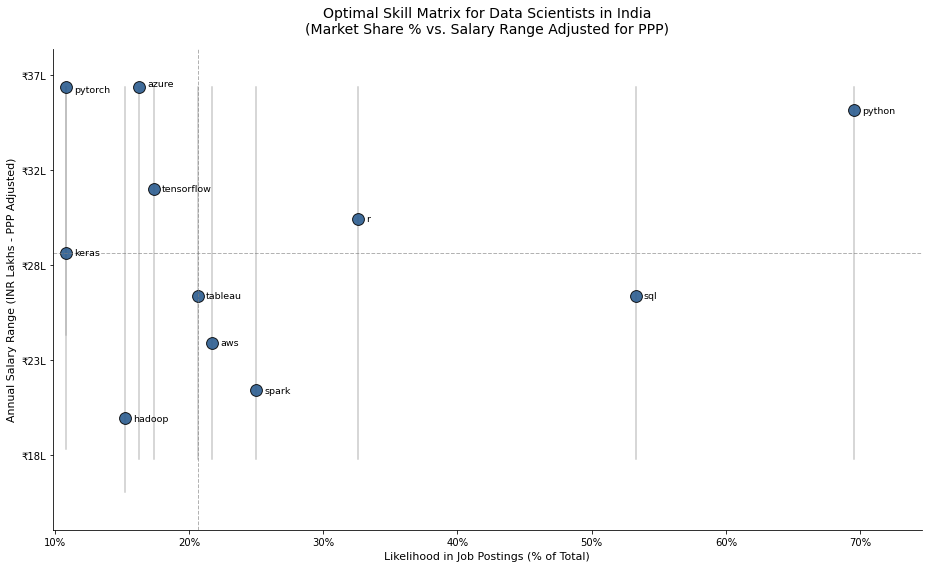

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np

# Create upper lower bounds of salary
df_optimal2_range = df_ds_indiaexplode.groupby('job_skills')['salary_year_avg'].agg(
    q25_salary=lambda x: np.percentile(x, 25),  # Lower bound salary floor
    q75_salary=lambda x: np.percentile(x, 75)   # Upper bound salary ceiling
).reset_index()

# make merge tables for skills and salary in one table
df_optimal2 = df_optimal2.merge(df_optimal2_range, on='job_skills', how='left')

# 2. Make the scatterplot:
fig, ax = plt.subplots(figsize=(13, 8)) 

for i in range(len(df_optimal2)):
    pct = df_optimal2['skill_percentage'].iloc[i]
    low = df_optimal2['q25_salary'].iloc[i]
    high = df_optimal2['q75_salary'].iloc[i]
    
    
    ax.plot([pct, pct], [low, high], color='#a8a8a8', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)

# 4. Plot using filtered 10% cutoff dataset 
sns.scatterplot(
    data=df_optimal2,
    x='skill_percentage',
    y='median_salary',
    s=140,
    color='#2b5c8f',
    alpha=0.9,
    edgecolor='black',
    ax=ax,
    zorder=2
)

# 5.Sort data as per median salary
df_sorted = df_optimal2.sort_values(by=['median_salary', 'skill_percentage'], ascending=[False, True]).reset_index(drop=True)

# Loop and place clean, right-side padded text labels (Keeping your exact original logic)
for i in range(len(df_sorted)):
    pct = df_sorted['skill_percentage'].iloc[i]
    sal = df_sorted['median_salary'].iloc[i]
    skill_name = df_sorted['job_skills'].iloc[i]
    
    x_offset = 0.6
    y_offset = 0
    
    if skill_name == 'azure':
        y_offset = 600
    elif skill_name == 'pytorch':
        y_offset = -600

    ax.text(
        x=pct + x_offset,
        y=sal + y_offset,
        s=skill_name,
        fontdict=dict(color='black', size=9.5),
        va='center',
        ha='left'
    )

# 6.Median range line
median_percentage = df_sorted['skill_percentage'].median()
median_pay = df_sorted['median_salary'].median()

ax.axvline(x=median_percentage, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=median_pay, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# 7. Format X-Axis:
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Convert using India's PPP factor (~23.5)
PPP_INR_FACTOR = 23.5 / 100000
ticks_y = mtick.FuncFormatter(lambda x, pos: f"₹{int(x * PPP_INR_FACTOR)}L")
ax.yaxis.set_major_formatter(ticks_y)

# 8.Title set
ax.set_title("Optimal Skill Matrix for Data Scientists in India\n(Market Share % vs. Salary Range Adjusted for PPP)", fontsize=14, pad=15)
ax.set_xlabel("Likelihood in Job Postings (% of Total)", fontsize=11)
ax.set_ylabel("Annual Salary Range (INR Lakhs - PPP Adjusted)", fontsize=11)


ax.set_xlim(df_sorted['skill_percentage'].min() - 1, df_sorted['skill_percentage'].max() + 5)
ax.set_ylim(df_optimal2['q25_salary'].min() - 8000, df_optimal2['q75_salary'].max() + 8000)

sns.despine()
plt.tight_layout()
plt.savefig('my_plot_ds.png', facecolor='white', transparent=False, bbox_inches='tight', dpi=300)
plt.show()